# Mock bias visualisation

Load pre-computed batch results from `scripts/runs/mwcepheids/mocks/collect_mock_simple.py` (simplified model) and `scripts/runs/mwcepheids/mocks/run_mock_forward.py` (forward model) and plot standardised bias distributions.

In [16]:
import os
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import scienceplots
from matplotlib.lines import Line2D

%matplotlib inline

In [21]:
results_dir = "../../results/mocks"

# Simple-model files: (filename, display_sigma_int)
simple_batch_files = [
    ("mock_batch.npz", 0.06),
    # ("mock_batch_sint0.100.npz", 0.10),
    ("mock_batch_sint0.150.npz", 0.15),
]

# Forward-model per-campaign files: (campaign, selection, sigma_int)
forward_campaigns = [
    ("C22", "mW"),
    ("C27", "pi"),
]
forward_sigma_ints = [0.06, 0.15]


def load_batch(fpath):
    """Load a combined batch .npz, return {label: {param: array}}."""
    data = np.load(fpath)
    labels = list(data["labels"])
    results = {}
    for label in labels:
        biases = {}
        for key in data:
            if key.startswith(f"{label}/"):
                p = key[len(label) + 1:]
                biases[p] = data[key]
        results[label] = biases
    n_mocks = int(data["n_mocks"]) if "n_mocks" in data else None
    return results, labels, n_mocks


def load_forward_campaign(fpath):
    """Load a per-campaign forward model .npz."""
    data = np.load(fpath)
    params = list(data["params"])
    biases = {p: data[p] for p in params if p in data}
    n_mocks = int(data["n_mocks"]) if "n_mocks" in data else None
    return biases, n_mocks


# Load simple model batches
all_batches = {}
for fname, sint in simple_batch_files:
    fpath = os.path.join(results_dir, fname)
    if not os.path.exists(fpath):
        print(f"[WARN] Missing {fpath}, skipping")
        continue
    results, labels, n_mocks = load_batch(fpath)
    all_batches[sint] = results
    print(f"Simple  sigma_int={sint}: {len(labels)} tasks, "
          f"n_mocks={n_mocks}")

# Load forward model per-campaign files
# all_forward[sigma_int][campaign] = biases dict
all_forward = {}
for sint in forward_sigma_ints:
    for camp, sel in forward_campaigns:
        label = f"{camp}_{sel}_si{sint:.4f}"
        fpath = os.path.join(results_dir, f"mock_forward_{label}.npz")
        if not os.path.exists(fpath):
            continue
        biases, n_mocks = load_forward_campaign(fpath)
        all_forward.setdefault(sint, {})[camp] = biases
        print(f"Forward sigma_int={sint}, {camp}: "
              f"{len(biases)} params, n_mocks={n_mocks}")

Simple  sigma_int=0.06: 5 tasks, n_mocks=10000
Simple  sigma_int=0.15: 5 tasks, n_mocks=10000
Forward sigma_int=0.06, C22: 9 params, n_mocks=10000
Forward sigma_int=0.06, C27: 9 params, n_mocks=10000
Forward sigma_int=0.15, C22: 9 params, n_mocks=10000
Forward sigma_int=0.15, C27: 9 params, n_mocks=10000


## Bias histograms per $\sigma_{\rm int}$

In [22]:
params_plot = ["MWH", "delta_pi"]
param_labels = {
    "MWH": r"$M^W_H$",
    "bW": r"$b_W$",
    "ZW": r"$Z_W$",
    "delta_pi": r"$\delta_\varpi$",
}

campaigns = ["C22", "C27"]
campaign_labels = {
    "C22": "Magnitude-selected (C22-like)",
    "C27": "Parallax-selected (C27-like)",
}

campaign_ltypes = {
    "C22": ["gaussian", "chi2"],
    "C27": ["parallax_selection", "chi2"],
}

# Forward model: campaign -> selection suffix used in label
campaign_forward_sel = {"C22": "mW", "C27": "pi"}

colours = ["#c52233", "#0e0004", "#2e8b57", "#3c91e6", "#f2a359"]
ltype_colors = {
    "gaussian": colours[0],
    "parallax_selection": colours[0],
    "chi2": colours[2],
    "forward": colours[3],
}

=== sigma_int = 0.06 ===
  C22 Linearised Gaussian........... MWH: -0.162 ± 1.008, delta_pi: -0.075 ± 1.007
  C22 chi2 (R21).................... MWH: +0.114 ± 1.013, delta_pi: +0.211 ± 1.006
  C22 Forward model................. MWH: -0.053 ± 0.988, delta_pi: -0.111 ± 1.020
  C27 Linearised Gaussian........... MWH: -0.128 ± 1.032, delta_pi: -0.056 ± 1.053
  C27 chi2 (R21).................... MWH: -0.148 ± 1.034, delta_pi: -0.264 ± 1.073
  C27 Forward model................. MWH: -0.017 ± 1.055, delta_pi: -0.020 ± 1.100



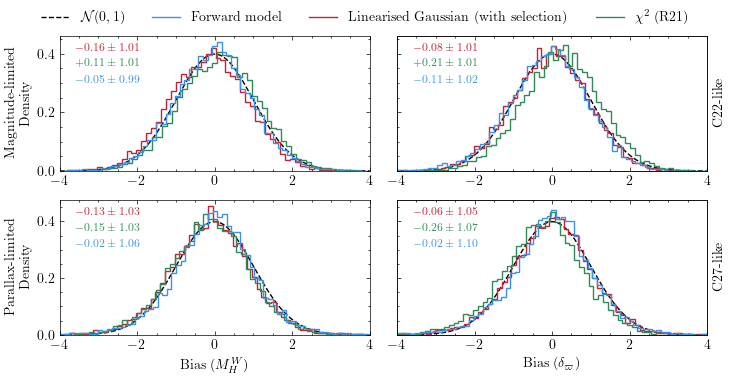

=== sigma_int = 0.15 ===
  C22 Linearised Gaussian........... MWH: -0.433 ± 1.008, delta_pi: -0.109 ± 1.001
  C22 chi2 (R21).................... MWH: +0.685 ± 1.006, delta_pi: +1.033 ± 0.950
  C22 Forward model................. MWH: -0.068 ± 1.050, delta_pi: -0.077 ± 1.060
  C27 Linearised Gaussian........... MWH: -0.266 ± 0.902, delta_pi: -0.001 ± 0.905
  C27 chi2 (R21).................... MWH: +0.201 ± 0.846, delta_pi: +0.037 ± 0.843
  C27 Forward model................. MWH: -0.009 ± 1.109, delta_pi: -0.031 ± 1.356



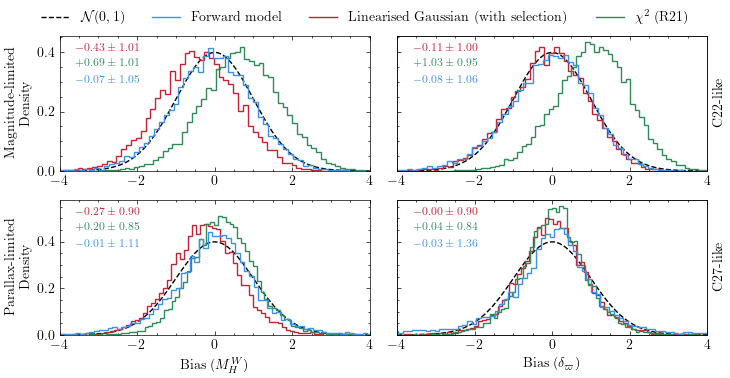

In [23]:
def strip_sint_suffix(label):
    """Remove _sintX.XXX or _siX.XXXX suffix from a label."""
    for prefix in ("_sint", "_si"):
        idx = label.find(prefix)
        if idx >= 0:
            return label[:idx]
    return label


def group_by_campaign(results):
    """Group results dict by campaign and likelihood type."""
    grouped = {c: {} for c in campaigns}
    for label, biases in results.items():
        short = strip_sint_suffix(label)
        for c in campaigns:
            if short.startswith(c + "_"):
                ltype = short[len(c) + 1:]
                grouped[c][ltype] = biases
    return grouped


campaign_ylabel = {
    "C22": "Magnitude-limited",
    "C27": "Parallax-limited",
}
campaign_rhs_label = {
    "C22": "C22-like",
    "C27": "C27-like",
}

ltype_display = {
    "gaussian": "Linearised Gaussian",
    "parallax_selection": "Linearised Gaussian",
    "chi2": "chi2 (R21)",
    "forward": "Forward model",
}

x = np.linspace(-4, 4, 200)

for sint, results in all_batches.items():
    grouped = group_by_campaign(results)
    fwd_data = all_forward.get(sint, {})

    print(f"=== sigma_int = {sint:.2f} ===")
    for camp in campaigns:
        fwd = fwd_data.get(camp)
        for ltype in campaign_ltypes[camp]:
            if ltype not in grouped[camp]:
                continue
            vals = []
            for p in params_plot:
                if p in grouped[camp][ltype]:
                    b = grouped[camp][ltype][p]
                    vals.append(f"{p}: {b.mean():+.3f} ± {b.std():.3f}")
            if vals:
                print(f"  {camp} {ltype_display[ltype]:.<30s} {', '.join(vals)}")
        if fwd is not None:
            vals = []
            for p in params_plot:
                if p in fwd:
                    b = fwd[p]
                    vals.append(f"{p}: {b.mean():+.3f} ± {b.std():.3f}")
            if vals:
                print(f"  {camp} {ltype_display['forward']:.<30s} {', '.join(vals)}")
    print()

    with plt.style.context("science"):
        fig, axes = plt.subplots(
            len(campaigns), len(params_plot),
            figsize=(3.75 * len(params_plot), 2. * len(campaigns)),
            squeeze=False, sharey="row")

        for i, camp in enumerate(campaigns):
            fwd = fwd_data.get(camp)

            for j, p in enumerate(params_plot):
                ax = axes[i, j]
                ax.plot(x, norm.pdf(x), "k--")

                text_lines = []
                for ltype in campaign_ltypes[camp]:
                    if ltype in grouped[camp] and p in grouped[camp][ltype]:
                        b = grouped[camp][ltype][p]
                        ax.hist(b, bins="auto", density=True,
                                histtype="step", color=ltype_colors[ltype])
                        text_lines.append(
                            (f"${b.mean():+.2f} \\pm {b.std():.2f}$",
                             ltype_colors[ltype]))

                # Forward model
                if fwd is not None and p in fwd:
                    b = fwd[p]
                    ax.hist(b, bins="auto", density=True,
                            histtype="step", color=ltype_colors["forward"])
                    text_lines.append(
                        (f"${b.mean():+.2f} \\pm {b.std():.2f}$",
                         ltype_colors["forward"]))

                for k, (txt, col) in enumerate(text_lines):
                    ax.text(0.05, 0.95 - k * 0.12, txt,
                            transform=ax.transAxes, ha="left", va="top",
                            fontsize=8, color=col)

                ax.set_xlim(-4, 4)
                if i == len(campaigns) - 1:
                    ax.set_xlabel(f"Bias ({param_labels[p]})")
                if j == 0:
                    ax.set_ylabel(
                        f"{campaign_ylabel[camp]}\nDensity")
                if j == len(params_plot) - 1:
                    ax_r = ax.twinx()
                    ax_r.set_yticks([])
                    ax_r.set_ylabel(campaign_rhs_label[camp])

        handles = [
            Line2D([], [], color="k", ls="--", lw=1,
                   label=r"$\mathcal{N}(0,1)$"),
            Line2D([], [], color=colours[3], lw=1,
                   label="Forward model"),
            Line2D([], [], color=colours[0], lw=1,
                   label="Linearised Gaussian (with selection)"),
            Line2D([], [], color=colours[2], lw=1,
                   label=r"$\chi^2$ (R21)"),
        ]

        fig.tight_layout()
        fig.legend(handles=handles, loc="upper center",
                   ncol=4, bbox_to_anchor=(0.5, 0.975),
                   frameon=False)
        fig.subplots_adjust(top=0.88)
        fig.savefig(f"/Users/rstiskalek/Downloads/mock_biases_sint{sint:.2f}.pdf", dpi=450)
        plt.show()


## All parameters

=== sigma_int = 0.06 ===
  C22 Linearised Gaussian........... MWH: -0.162 ± 1.008, bW: -0.053 ± 0.989, ZW: +0.231 ± 0.997, delta_pi: -0.075 ± 1.007
  C22 chi2 (R21).................... MWH: +0.114 ± 1.013, bW: +0.129 ± 0.995, ZW: +0.241 ± 0.997, delta_pi: +0.211 ± 1.006
  C22 Forward model................. MWH: -0.053 ± 0.988, bW: -0.079 ± 0.991, ZW: -0.026 ± 0.968, delta_pi: -0.111 ± 1.020
  C27 Linearised Gaussian........... MWH: -0.128 ± 1.032, bW: -0.003 ± 1.009, ZW: +0.312 ± 1.005, delta_pi: -0.056 ± 1.053
  C27 chi2 (R21).................... MWH: -0.148 ± 1.034, bW: -0.002 ± 1.006, ZW: +0.311 ± 1.002, delta_pi: -0.264 ± 1.073
  C27 Forward model................. MWH: -0.017 ± 1.055, bW: -0.003 ± 0.992, ZW: -0.039 ± 0.982, delta_pi: -0.020 ± 1.100



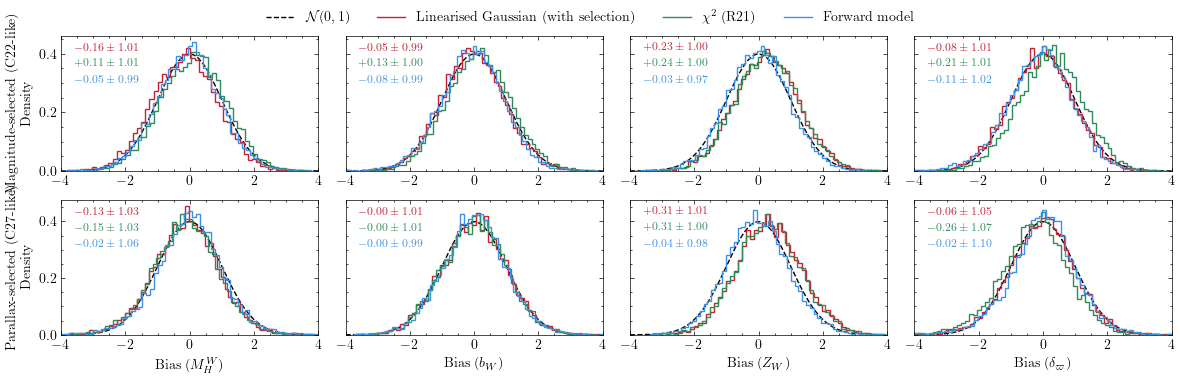

=== sigma_int = 0.15 ===
  C22 Linearised Gaussian........... MWH: -0.433 ± 1.008, bW: -0.064 ± 0.980, ZW: +0.159 ± 0.995, delta_pi: -0.109 ± 1.001
  C22 chi2 (R21).................... MWH: +0.685 ± 1.006, bW: +0.769 ± 1.009, ZW: +0.205 ± 0.975, delta_pi: +1.033 ± 0.950
  C22 Forward model................. MWH: -0.068 ± 1.050, bW: -0.054 ± 1.067, ZW: -0.060 ± 1.065, delta_pi: -0.077 ± 1.060
  C27 Linearised Gaussian........... MWH: -0.266 ± 0.902, bW: -0.006 ± 1.013, ZW: +0.188 ± 0.998, delta_pi: -0.001 ± 0.905
  C27 chi2 (R21).................... MWH: +0.201 ± 0.846, bW: -0.008 ± 0.988, ZW: +0.185 ± 0.971, delta_pi: +0.037 ± 0.843
  C27 Forward model................. MWH: -0.009 ± 1.109, bW: -0.008 ± 1.047, ZW: -0.021 ± 1.040, delta_pi: -0.031 ± 1.356



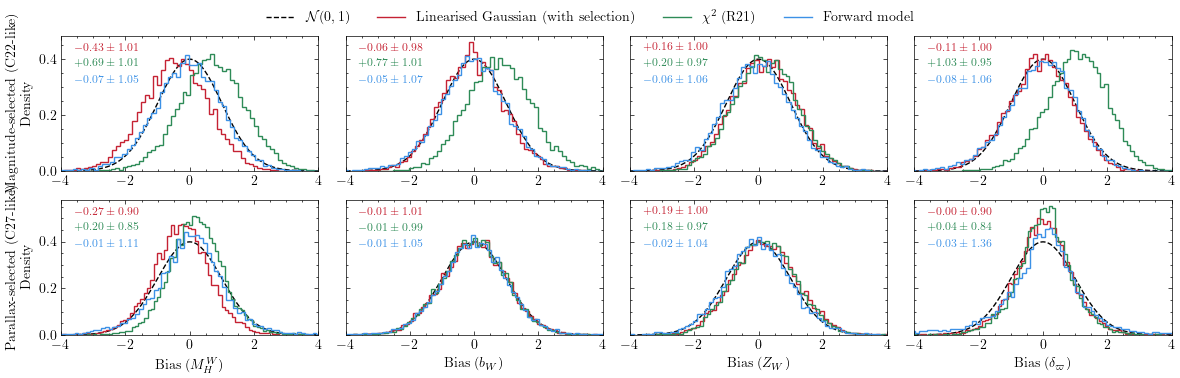

In [20]:
all_params = ["MWH", "bW", "ZW", "delta_pi"]

ltype_display = {
    "gaussian": "Linearised Gaussian",
    "parallax_selection": "Linearised Gaussian",
    "chi2": "chi2 (R21)",
    "forward": "Forward model",
}

for sint, results in all_batches.items():
    grouped = group_by_campaign(results)
    fwd_data = all_forward.get(sint, {})

    print(f"=== sigma_int = {sint:.2f} ===")
    for camp in campaigns:
        fwd = fwd_data.get(camp)
        for ltype in campaign_ltypes[camp]:
            if ltype not in grouped[camp]:
                continue
            vals = []
            for p in all_params:
                if p in grouped[camp][ltype]:
                    b = grouped[camp][ltype][p]
                    vals.append(f"{p}: {b.mean():+.3f} ± {b.std():.3f}")
            if vals:
                print(f"  {camp} {ltype_display[ltype]:.<30s} {', '.join(vals)}")
        if fwd is not None:
            vals = []
            for p in all_params:
                if p in fwd:
                    b = fwd[p]
                    vals.append(f"{p}: {b.mean():+.3f} ± {b.std():.3f}")
            if vals:
                print(f"  {camp} {ltype_display['forward']:.<30s} {', '.join(vals)}")
    print()

    with plt.style.context("science"):
        fig, axes = plt.subplots(
            len(campaigns), len(all_params),
            figsize=(3 * len(all_params), 2. * len(campaigns)),
            squeeze=False, sharey="row")

        for i, camp in enumerate(campaigns):
            fwd = fwd_data.get(camp)

            for j, p in enumerate(all_params):
                ax = axes[i, j]
                ax.plot(x, norm.pdf(x), "k--")

                text_lines = []
                for ltype in campaign_ltypes[camp]:
                    if ltype in grouped[camp] and p in grouped[camp][ltype]:
                        b = grouped[camp][ltype][p]
                        ax.hist(b, bins="auto", density=True,
                                histtype="step", color=ltype_colors[ltype])
                        text_lines.append(
                            (f"${b.mean():+.2f} \\pm {b.std():.2f}$",
                             ltype_colors[ltype]))

                # Forward model
                if fwd is not None and p in fwd:
                    b = fwd[p]
                    ax.hist(b, bins="auto", density=True,
                            histtype="step", color=ltype_colors["forward"])
                    text_lines.append(
                        (f"${b.mean():+.2f} \\pm {b.std():.2f}$",
                         ltype_colors["forward"]))

                for k, (txt, col) in enumerate(text_lines):
                    ax.text(0.05, 0.95 - k * 0.12, txt,
                            transform=ax.transAxes, ha="left", va="top",
                            fontsize=8, color=col)

                ax.set_xlim(-4, 4)
                if i == len(campaigns) - 1:
                    ax.set_xlabel(f"Bias ({param_labels[p]})")
                if j == 0:
                    ax.set_ylabel(
                        f"{campaign_labels[camp]}\nDensity")

        handles = [
            Line2D([], [], color="k", ls="--", lw=1,
                   label=r"$\mathcal{N}(0,1)$"),
            Line2D([], [], color=colours[0], lw=1,
                   label="Linearised Gaussian (with selection)"),
            Line2D([], [], color=colours[2], lw=1,
                   label=r"$\chi^2$ (R21)"),
            Line2D([], [], color=colours[3], lw=1,
                   label="Forward model"),
        ]

        fig.tight_layout()
        fig.legend(handles=handles, loc="upper center",
                   ncol=4, bbox_to_anchor=(0.5, 0.975),
                   frameon=False)
        fig.subplots_adjust(top=0.88)
        fig.savefig(f"/Users/rstiskalek/Downloads/mock_biases_all_sint{sint:.2f}.pdf", dpi=450)
        plt.show()
